Searching for images in /kaggle/input/...
✅ Success! Found 2639 images.
Testing pipeline on: /kaggle/input/datasets/swoyam2609/casia-iris-interval/CASIA-Iris-Interval/248/R/S1248R07.jpg



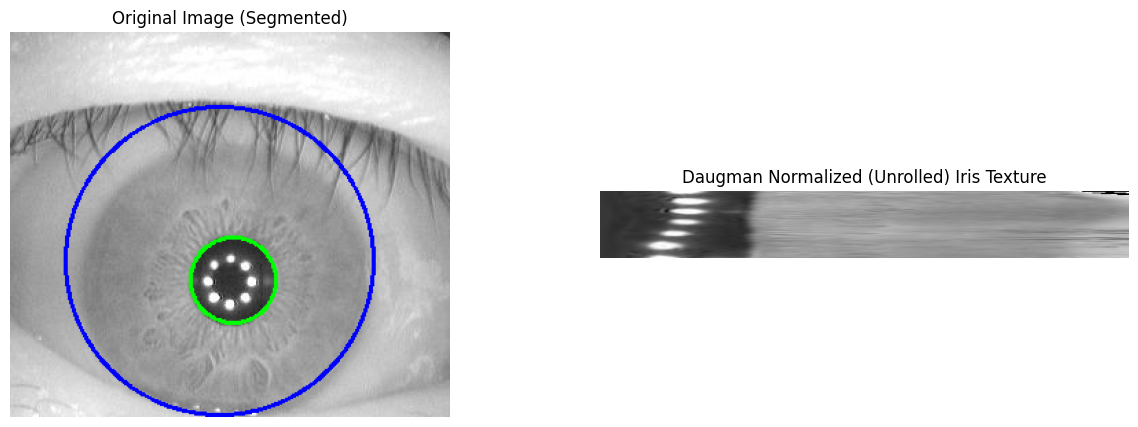

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def segment_and_unroll_iris(image_path):
    # 1. Load the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None, None, None

    # Apply a Gaussian blur to reduce eyelash/reflection noise
    blurred = cv2.GaussianBlur(img, (7, 7), 0)

    # 2. Find the Pupil (Dark inner circle)
    # Param1/Param2 are sensitivity thresholds tuned for CASIA-Interval
    pupil_circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=200,
        param1=50, param2=30, minRadius=20, maxRadius=70
    )

    if pupil_circles is not None:
        pupil_circles = np.uint16(np.around(pupil_circles))
        pupil_x, pupil_y, pupil_r = pupil_circles[0, 0]
    else:
        return img, None, None, None

    # 3. Find the Iris Boundary (Outer circle)
    iris_circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=200,
        param1=50, param2=30, minRadius=pupil_r + 20, maxRadius=160
    )

    if iris_circles is not None:
        iris_circles = np.uint16(np.around(iris_circles))
        iris_x, iris_y, iris_r = iris_circles[0, 0]
    else:
        return img, None, None, None

    # 4. Daugman's Rubber Sheet Model (Unrolling)
    # Unroll the circular ring into a flat rectangle using Polar coordinates
    unrolled = cv2.warpPolar(
        img, 
        dsize=(360, iris_r), # 360 degrees of width, outer radius as height
        center=(pupil_x, pupil_y),
        maxRadius=iris_r,
        flags=cv2.INTER_LINEAR + cv2.WARP_POLAR_LINEAR
    )

    # Crop out the pupil (the black void) to leave strictly the iris texture
    iris_texture = unrolled[pupil_r:iris_r, :]

    # Resize to a standardized grid (64x512) to prepare for Gabor filtering
    normalized_iris = cv2.resize(iris_texture, (512, 64))

    return img, normalized_iris, (pupil_x, pupil_y, pupil_r), (iris_x, iris_y, iris_r)

# ==========================================
# TEST THE PIPELINE ON A SINGLE IMAGE
# ==========================================
# ==========================================
# FOOLPROOF DATASET SEARCH & TEST
# ==========================================

import os
import glob

print("Searching for images in /kaggle/input/...")

# Search recursively for both .jpg and .bmp files (CASIA uses both)
all_images = glob.glob('/kaggle/input/**/*.jpg', recursive=True)
all_images += glob.glob('/kaggle/input/**/*.bmp', recursive=True)

if len(all_images) > 0:
    test_img_path = all_images[0] # Grab the very first image found
    print(f"✅ Success! Found {len(all_images)} images.")
    print(f"Testing pipeline on: {test_img_path}\n")
    
    # Run our function
    original_img, unrolled_img, pupil, iris = segment_and_unroll_iris(test_img_path)
    
    if unrolled_img is not None:
        # Plot the results side-by-side
        fig, axs = plt.subplots(1, 2, figsize=(15, 5))
        
        # Draw circles on original image for visualization
        display_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)
        cv2.circle(display_img, (pupil[0], pupil[1]), pupil[2], (0, 255, 0), 2) # Green Pupil
        cv2.circle(display_img, (iris[0], iris[1]), iris[2], (255, 0, 0), 2)    # Blue Iris
        
        axs[0].imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
        axs[0].set_title("Original Image (Segmented)")
        axs[0].axis('off')
        
        axs[1].imshow(unrolled_img, cmap='gray')
        axs[1].set_title("Daugman Normalized (Unrolled) Iris Texture")
        axs[1].axis('off')
        
        plt.show()
    else:
        print("❌ Could not detect pupil/iris in the sample image. The Hough thresholds might need tweaking for this specific image.")
else:
    print("❌ Still can't find any images.")
    print("Let's look at exactly what folders exist in your input directory:")
    for root, dirs, files in os.walk('/kaggle/input/'):
        print(f"Directory: {root}")

Building topological graph from iris texture...
✅ Graph constructed! Nodes: 135 | Edges: 407


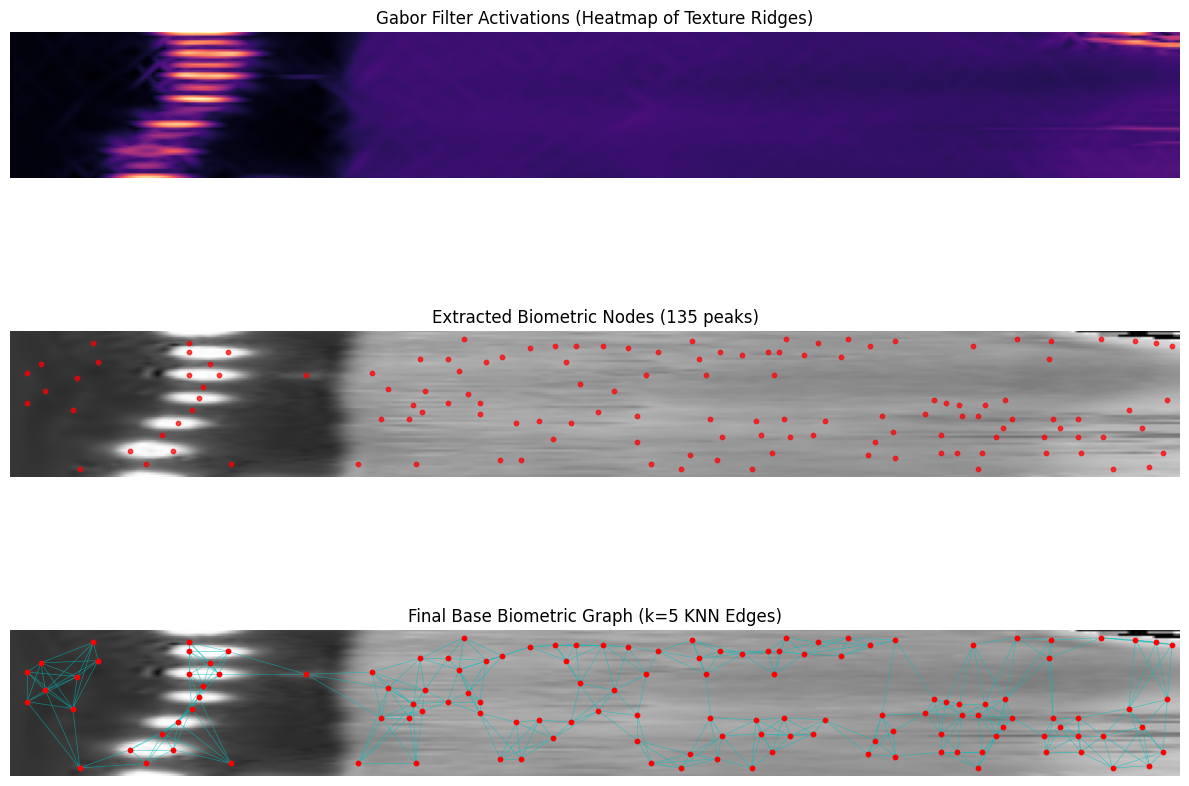

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max  # <--- THIS IS THE CORRECTED IMPORT
from sklearn.neighbors import NearestNeighbors
import networkx as nx

# ---------------------------------------------------------
# 1. THE FUNCTION DEFINITION
# ---------------------------------------------------------
def build_iris_graph(unrolled_img, num_nodes=400, k_neighbors=5):
    """
    Applies Gabor filters to extract topological nodes and builds a KNN graph.
    """
    # Build a bank of Gabor filters (different orientations)
    gabor_kernels = []
    ksize = 15 # Size of the filter
    sigma = 3.0 # Standard deviation of the gaussian envelope
    lambd = 7.0 # Wavelength of the sinusoidal factor
    gamma = 0.5 # Spatial aspect ratio
    
    # We create filters at 4 different angles (0, 45, 90, 135 degrees)
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, 0, ktype=cv2.CV_32F)
        gabor_kernels.append(kernel)

    # Apply filters to the unrolled image and combine responses
    accumulated_response = np.zeros_like(unrolled_img, dtype=np.float32)
    for kernel in gabor_kernels:
        filtered = cv2.filter2D(unrolled_img, cv2.CV_32F, kernel)
        np.maximum(accumulated_response, np.abs(filtered), accumulated_response)

    # Extract Nodes (The highest activation peaks)
    coordinates = peak_local_max(accumulated_response, min_distance=3, num_peaks=num_nodes)
    nodes = np.fliplr(coordinates) # Flip (y,x) to (x,y)

    # Build the Edges (K-Nearest Neighbors)
    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1, algorithm='ball_tree').fit(nodes)
    distances, indices = nbrs.kneighbors(nodes)

    # Create a formal NetworkX graph
    G = nx.Graph()
    for i, (x, y) in enumerate(nodes):
        G.add_node(i, pos=(x, y))
        
    for i in range(len(nodes)):
        for j in range(1, k_neighbors + 1): 
            neighbor_index = indices[i][j]
            weight = distances[i][j]
            G.add_edge(i, neighbor_index, weight=weight)

    return G, nodes, accumulated_response

# ---------------------------------------------------------
# 2. TEST THE GRAPH EXTRACTOR
# ---------------------------------------------------------
if 'unrolled_img' in locals() and unrolled_img is not None:
    print("Building topological graph from iris texture...")
    
    G, nodes, gabor_response = build_iris_graph(unrolled_img, num_nodes=400, k_neighbors=5)
    
    print(f"✅ Graph constructed! Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    
    # Visualization
    fig, axs = plt.subplots(3, 1, figsize=(12, 10))
    
    # Show the Gabor Response
    axs[0].imshow(gabor_response, cmap='magma')
    axs[0].set_title("Gabor Filter Activations (Heatmap of Texture Ridges)")
    axs[0].axis('off')
    
    # Show the Extracted Nodes
    axs[1].imshow(unrolled_img, cmap='gray')
    axs[1].scatter(nodes[:, 0], nodes[:, 1], c='red', s=10, alpha=0.7)
    axs[1].set_title(f"Extracted Biometric Nodes ({len(nodes)} peaks)")
    axs[1].axis('off')
    
    # Show the Full Mathematical Graph (Nodes + Edges)
    axs[2].imshow(unrolled_img, cmap='gray')
    for edge in G.edges():
        pt1 = nodes[edge[0]]
        pt2 = nodes[edge[1]]
        axs[2].plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], 'c-', linewidth=0.5, alpha=0.6)
    
    axs[2].scatter(nodes[:, 0], nodes[:, 1], c='red', s=10, zorder=5)
    axs[2].set_title("Final Base Biometric Graph (k=5 KNN Edges)")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Please run the previous cell first so 'unrolled_img' is stored in memory.")

🔐 Simulating User PIN: 1234
SHA-256 Hash derived: 03ac674216f3e15c...
Original Nodes: 135 | Chaff Injected: 67
Total Entangled Nodes: 202 | Edges: 603


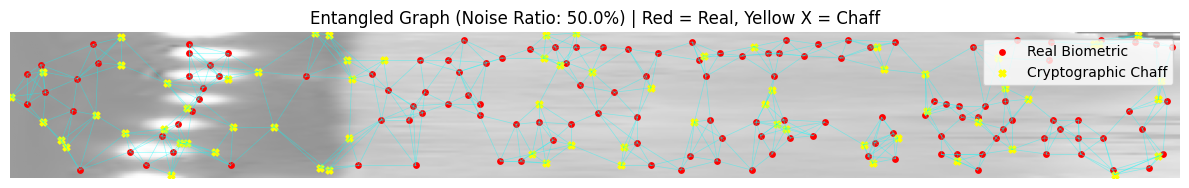

In [10]:
import hashlib
import numpy as np
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

def entangle_biometric_with_key(real_nodes, pin, noise_ratio=0.25, img_shape=(512, 64), k_neighbors=5):
    """
    Injects cryptographic chaff nodes and structurally entangles them via KNN.
    img_shape is (width, height)
    """
    # 1. Cryptographic Key Derivation (SHA-256)
    hash_obj = hashlib.sha256(pin.encode())
    hex_hash = hash_obj.hexdigest()
    
    # Convert the first 8 characters of the hash to a 32-bit integer seed for our PRNG
    seed = int(hex_hash[:8], 16) % (2**32)
    rng = np.random.default_rng(seed)
    
    # 2. Generate Chaff Nodes
    num_real = len(real_nodes)
    num_chaff = int(num_real * noise_ratio)
    
    # Generate random (x, y) coordinates for chaff within the unrolled image bounds
    chaff_x = rng.integers(0, img_shape[0], size=num_chaff)
    chaff_y = rng.integers(0, img_shape[1], size=num_chaff)
    chaff_nodes = np.column_stack((chaff_x, chaff_y))
    
    # 3. Combine Real and Fake Nodes
    combined_nodes = np.vstack((real_nodes, chaff_nodes))
    
    # Create labels for visualization (1 = Real, 0 = Chaff)
    labels = np.array([1]*num_real + [0]*num_chaff)
    
    # 4. The Entanglement (Re-run KNN on the combined set)
    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1, algorithm='ball_tree').fit(combined_nodes)
    distances, indices = nbrs.kneighbors(combined_nodes)
    
    # Build the new entangled NetworkX graph
    G_entangled = nx.Graph()
    for i, (x, y) in enumerate(combined_nodes):
        G_entangled.add_node(i, pos=(x, y), is_real=labels[i])
        
    for i in range(len(combined_nodes)):
        for j in range(1, k_neighbors + 1):
            neighbor_idx = indices[i][j]
            weight = distances[i][j]
            G_entangled.add_edge(i, neighbor_idx, weight=weight)
            
    return G_entangled, combined_nodes, labels, hex_hash

# ==========================================
# TEST THE CRYPTOGRAPHIC ENTANGLEMENT
# ==========================================
if 'nodes' in locals():
    test_pin = "1234"
    noise_level = 0.50 # Injecting 50% fake nodes
    
    print(f"🔐 Simulating User PIN: {test_pin}")
    
    G_ent, ent_nodes, node_labels, hash_val = entangle_biometric_with_key(
        real_nodes=nodes, 
        pin=test_pin, 
        noise_ratio=noise_level
    )
    
    print(f"SHA-256 Hash derived: {hash_val[:16]}...")
    print(f"Original Nodes: {len(nodes)} | Chaff Injected: {len(ent_nodes) - len(nodes)}")
    print(f"Total Entangled Nodes: {G_ent.number_of_nodes()} | Edges: {G_ent.number_of_edges()}")
    
    # Visualization
    plt.figure(figsize=(12, 4))
    plt.imshow(unrolled_img, cmap='gray', alpha=0.5)
    
    # Plot the entangled edges first
    for edge in G_ent.edges():
        pt1 = ent_nodes[edge[0]]
        pt2 = ent_nodes[edge[1]]
        plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], color='cyan', linewidth=0.5, alpha=0.4)
        
    # Plot real nodes (red) and chaff nodes (yellow X's)
    real_mask = node_labels == 1
    chaff_mask = node_labels == 0
    
    plt.scatter(ent_nodes[real_mask][:, 0], ent_nodes[real_mask][:, 1], c='red', s=15, label='Real Biometric')
    plt.scatter(ent_nodes[chaff_mask][:, 0], ent_nodes[chaff_mask][:, 1], c='yellow', s=25, marker='X', label='Cryptographic Chaff')
    
    plt.title(f"Entangled Graph (Noise Ratio: {noise_level*100}%) | Red = Real, Yellow X = Chaff")
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Please ensure the 'nodes' array from the previous cell is loaded.")

In [12]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.3 MB/s eta 0:00:00a 0:00:01


In [15]:
import torch
from torch_geometric.data import Data
from tqdm import tqdm
import os
import re
import numpy as np

def convert_to_pyg_data(G_nx, node_features, labels, subject_id):
    """Converts our NetworkX graph into a PyTorch Geometric Data object."""
    # Node features: [x_coord, y_coord, is_real_flag]
    x = torch.tensor(np.column_stack((node_features, labels)), dtype=torch.float)
    
    # Extract edges
    edges = list(G_nx.edges())
    if len(edges) > 0:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        # Make edges undirected for PyG
        edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        
    # Label is the Subject ID
    y = torch.tensor([subject_id], dtype=torch.long)
    
    return Data(x=x, edge_index=edge_index, y=y)

# ==========================================
# THE BIG RUN: BULK PROCESSING PIPELINE
# ==========================================

# Lists to hold our PyTorch datasets
dataset_base = []  # 0% Noise
dataset_10 = []    # 10% Noise
dataset_25 = []    # 25% Noise
dataset_50 = []    # 50% Noise

# ⚠️ TESTING LIMIT: Set to all_images[:20] for a quick test. 
# Change to simply `all_images` when you are ready for the final run.
images_to_process = all_images

print(f"Starting bulk processing for {len(images_to_process)} images...")

for img_path in tqdm(images_to_process, desc="Processing Iris Graphs"):
    
    # 1. Extract Subject ID from filename (e.g., 'S1248R07.jpg' -> 1248)
    filename = os.path.basename(img_path) # <--- THIS IS THE FIXED LINE
    match = re.search(r'S(\d{4})', filename)
    if not match:
        continue # Skip if filename format is weird
    subject_id = int(match.group(1))
    
    # 2. Segment and Unroll
    _, unrolled, _, _ = segment_and_unroll_iris(img_path)
    if unrolled is None:
        continue
        
    # 3. Extract Base Graph (0% Noise)
    G_base, nodes, _ = build_iris_graph(unrolled, num_nodes=400, k_neighbors=5)
    
    # If the image was too blurry to extract enough nodes, skip it
    if len(nodes) < 50: 
        continue
        
    # Convert and save base graph
    pyg_base = convert_to_pyg_data(G_base, nodes, [1]*len(nodes), subject_id)
    dataset_base.append(pyg_base)
    
    # 4. Generate Entangled Graphs (Ablation Variations)
    # We use a static PIN here to simulate the user's master key
    static_pin = "1234"
    
    for noise_level, dataset_list in zip([0.10, 0.25, 0.50], [dataset_10, dataset_25, dataset_50]):
        G_ent, ent_nodes, labels, _ = entangle_biometric_with_key(
            real_nodes=nodes, pin=static_pin, noise_ratio=noise_level
        )
        pyg_entangled = convert_to_pyg_data(G_ent, ent_nodes, labels, subject_id)
        dataset_list.append(pyg_entangled)

# 5. Save the Datasets to Disk
print("\nSaving PyTorch datasets to /kaggle/working/...")
torch.save(dataset_base, '/kaggle/working/iris_graphs_base.pt')
torch.save(dataset_10, '/kaggle/working/iris_graphs_10.pt')
torch.save(dataset_25, '/kaggle/working/iris_graphs_25.pt')
torch.save(dataset_50, '/kaggle/working/iris_graphs_50.pt')

print("✅ Big Run Complete! Datasets saved successfully.")

Starting bulk processing for 2639 images...


Processing Iris Graphs: 100%|██████████| 2639/2639 [02:37<00:00, 16.77it/s]



Saving PyTorch datasets to /kaggle/working/...
✅ Big Run Complete! Datasets saved successfully.
